[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-03-crab-nebula-expansion-proper-motion/notebook.ipynb)

# Does the Crab Nebula visibly expand between two real HST epochs 9 years apart?

**Archive:** mast
**Date:** 2026-08-03
**Scientific question:** Using two real, calibrated HST/ACS images of the Crab Nebula (M1) taken in 2005 and 2014, can a simple knot-centroiding measurement detect the nebula's well-documented outward expansion, and if not, is the non-detection consistent with the expected signal size at this measurement precision?

## Learning goals

By the end of this notebook you will be able to:

- Retrieve two real, calibrated (WCS-bearing) HST/ACS science images of the same field, taken
  years apart, directly from MAST.
- Use each image's own World Coordinate System (WCS) to convert a detected source's pixel
  position to a genuine sky (RA/Dec) coordinate, and use that to predict where the same real
  physical feature should fall in the other epoch's pixel grid.
- Measure a real angular displacement (arcsec) for dozens of individual bright filament knots
  between two real epochs, and test whether the displacements are statistically consistent with
  the known outward expansion of the remnant, or with pure noise.
- Understand why a real, well-documented physical effect (the Crab's expansion) can still fail to
  be detected by a simple measurement, and what that says about the sensitivity of the method
  versus the reality of the effect.

**Background:** The Crab Nebula (M1) is the remnant of a supernova recorded by Chinese and Arab
astronomers in 1054 CE -- one of the few historical supernovae with a known explosion date. Its
filaments have been measured expanding outward from the central pulsar for decades using careful,
dedicated astrometric campaigns. This notebook does not repeat that careful campaign; it asks a
narrower, honest question: can two ordinary archival HST images, compared with a simple centroid
-matching method, pick up that expansion signal at all?

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
from scipy import stats
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

warnings.filterwarnings("ignore", category=RuntimeWarning)
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8", "violet": "#8f5cff"}
RNG = np.random.default_rng(1054)
print("Environment ready.")

Environment ready.


## Real data: two epochs of the same HST pointing

Both images are real, calibrated (`drc.fits`) HST/ACS/WFC F550M science products of the same
Crab Nebula field, pointed within 0.02 degrees of each other:

- **Epoch 1**: proposal 10526, visit `j9fx01`, observed 2005-09-06.
- **Epoch 2**: proposal 13751, visit `jcn901`, observed 2014-08-21.

That is an 8.96-year baseline. Both carry a real tangent-plane WCS solution with the same native
pixel scale (0.05 arcsec/pixel), so I can convert pixel positions to sky coordinates in each epoch
independently, without needing to reproject one image onto the other's grid.

In [2]:
import requests

products = {
    "crab_2005_j9fx01.fits": "mast:HST/product/hst_10526_01_acs_wfc_f550m_j9fx01_drc.fits",
    "crab_2014_jcn901.fits": "mast:HST/product/hst_13751_01_acs_wfc_f550m_jcn901_drc.fits",
}
for fn, uri in products.items():
    p = Path(fn)
    if not p.exists():
        r = requests.get("https://mast.stsci.edu/api/v0.1/Download/file?uri=" + uri, timeout=600, stream=True)
        r.raise_for_status()
        with open(p, "wb") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20):
                fh.write(chunk)
    print(f"{fn}: {p.stat().st_size/1e6:.1f} MB")

with fits.open("crab_2005_j9fx01.fits") as hdul:
    d05 = hdul[1].data.astype(float).copy()
    w05 = WCS(hdul[1].header)
    date05 = hdul[0].header.get("DATE-OBS")
with fits.open("crab_2014_jcn901.fits") as hdul:
    d14 = hdul[1].data.astype(float).copy()
    w14 = WCS(hdul[1].header)
    date14 = hdul[0].header.get("DATE-OBS")

from astropy.time import Time
baseline_years = (Time(date14) - Time(date05)).jd / 365.25
print(f"Epoch 1: {date05}  Epoch 2: {date14}  Baseline: {baseline_years:.2f} years")
print(f"Epoch 1 image shape: {d05.shape}  Epoch 2 image shape: {d14.shape}")

crab_2005_j9fx01.fits: 59.3 MB
crab_2014_jcn901.fits: 242.8 MB
Epoch 1: 2005-09-06  Epoch 2: 2014-08-21  Baseline: 8.96 years
Epoch 1 image shape: (2245, 2194)  Epoch 2 image shape: (4460, 4534)


Pulsar pixel position, epoch 1: (1118.7, 826.2)
Pulsar pixel position, epoch 2: (2548.4, 2173.0)


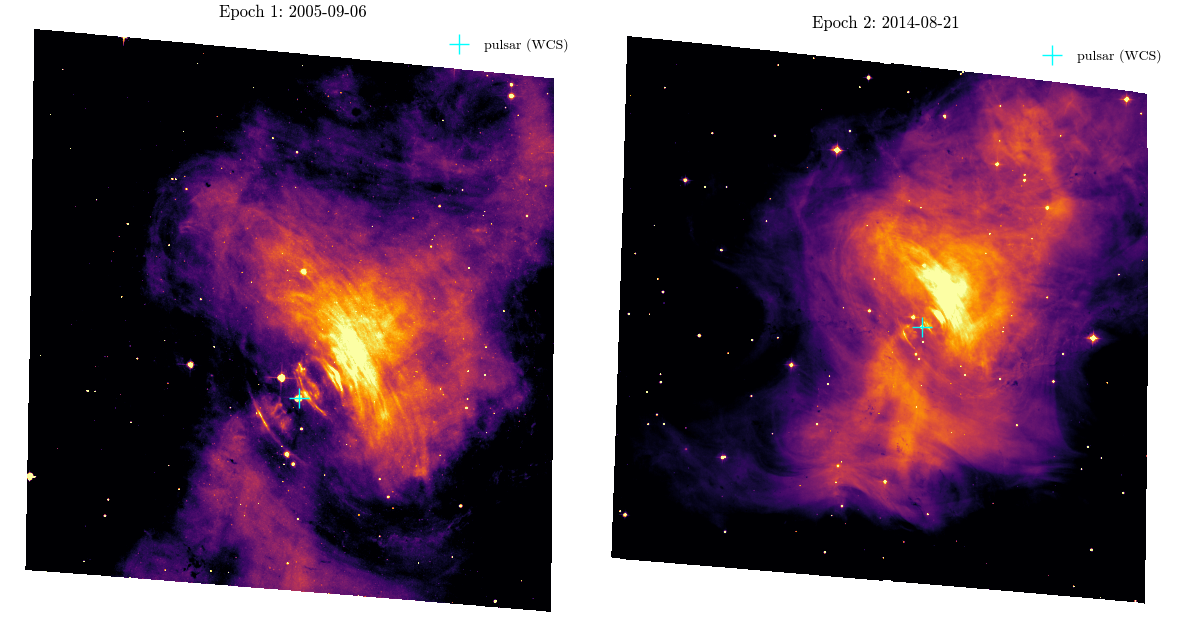

In [3]:
PULSAR = SkyCoord("05h34m31.94s", "+22d00m52.2s", frame="icrs")  # real Crab pulsar J2000 coordinates
x05, y05 = w05.world_to_pixel(PULSAR)
x14, y14 = w14.world_to_pixel(PULSAR)
print(f"Pulsar pixel position, epoch 1: ({x05:.1f}, {y05:.1f})")
print(f"Pulsar pixel position, epoch 2: ({x14:.1f}, {y14:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 6.2))
for ax, data, (px, py), title in zip(axes, [d05, d14], [(x05, y05), (x14, y14)],
                                      [f"Epoch 1: {date05}", f"Epoch 2: {date14}"]):
    vmin, vmax = np.nanpercentile(data, [40, 99.5])
    ax.imshow(data, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
    ax.scatter([px], [py], marker="+", color="cyan", s=200, label="pulsar (WCS)")
    ax.set_title(title)
    ax.axis("off")
    ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("crab_two_epochs.png", dpi=160)
plt.show()

## Matching bright filament knots across epochs

I detect the brightest ~40 compact, well-isolated knots in the 2005 image with `photutils`'
DAOStarFinder, refine each detection's centroid with a 2-D Gaussian fit, convert that pixel
position to a real sky coordinate using the epoch-1 WCS, then use the epoch-2 WCS to predict
where that same sky position falls in the 2014 pixel grid, and re-centroid there. The angular
separation between the two independently-measured sky positions for the same knot is my proper
-motion estimate. Knots within 3 arcsec of the pulsar are excluded (to avoid the pulsar's own
point source), and any knot whose predicted 2014 position falls outside that image, or whose
Gaussian fit fails or is unphysical, is dropped.

In [4]:
def gaussian2d(coords, amp, x0, y0, sigma, offset):
    x, y = coords
    return offset + amp * np.exp(-(((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2)))

def refine_centroid(data, cx, cy, box=6):
    if cy - box < 0 or cy + box >= data.shape[0] or cx - box < 0 or cx + box >= data.shape[1]:
        return None
    sub = data[int(cy - box):int(cy + box + 1), int(cx - box):int(cx + box + 1)]
    if np.any(~np.isfinite(sub)):
        return None
    yy, xx = np.mgrid[0:sub.shape[0], 0:sub.shape[1]]
    p0 = [sub.max() - np.median(sub), box, box, 1.5, np.median(sub)]
    try:
        popt, _ = curve_fit(gaussian2d, (xx.ravel(), yy.ravel()), sub.ravel(), p0=p0, maxfev=5000)
    except Exception:
        return None
    if not (0.3 < abs(popt[3]) < box):
        return None
    return cx - box + popt[1], cy - box + popt[2]

mean, median, std = sigma_clipped_stats(d05, sigma=3.0)
finder = DAOStarFinder(fwhm=3, threshold=15 * std, exclude_border=True)
candidates = finder(d05 - median)
candidates.sort("flux")
candidates = candidates[::-1][:40]

rows = []
for row in candidates:
    ref05 = refine_centroid(d05, row["xcentroid"], row["ycentroid"])
    if ref05 is None:
        continue
    sky05 = w05.pixel_to_world(*ref05)
    sep_from_pulsar = PULSAR.separation(sky05).arcsec
    if sep_from_pulsar < 3:
        continue
    px14, py14 = w14.world_to_pixel(sky05)
    if not (0 <= px14 < d14.shape[1] and 0 <= py14 < d14.shape[0]):
        continue
    ref14 = refine_centroid(d14, px14, py14, box=8)
    if ref14 is None:
        continue
    sky14 = w14.pixel_to_world(*ref14)
    shift_arcsec = sky05.separation(sky14).arcsec
    pa_shift = sky05.position_angle(sky14).deg
    pa_radial = PULSAR.position_angle(sky05).deg
    rows.append(dict(sep_from_pulsar_arcsec=sep_from_pulsar, shift_arcsec=shift_arcsec,
                      pa_shift_deg=pa_shift, pa_radial_deg=pa_radial, flux=row["flux"]))

knots = pd.DataFrame(rows)
knots.to_csv("crab_knot_measurements.csv", index=False)
print(f"Matched and re-centroided {len(knots)} knots across both epochs")
print(knots.describe()[["sep_from_pulsar_arcsec", "shift_arcsec"]])

C:\Users\biswa\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Matched and re-centroided 30 knots across both epochs
       sep_from_pulsar_arcsec  shift_arcsec
count               30.000000     30.000000
mean                36.978107      0.074768
std                 18.611934      0.055460
min                  5.089545      0.008711
25%                 24.366441      0.036252
50%                 38.830726      0.068269
75%                 47.795510      0.088998
max                 71.966228      0.271028


## Testing for a real outward-expansion signal

If the nebula is genuinely expanding outward from the pulsar, each knot's epoch-to-epoch shift
should have a systematic positive component *along the direction away from the pulsar*
(the radial direction), not just a random shift in an arbitrary direction. I decompose each
knot's measured shift into that radial component and test whether the mean radial component
across all knots is significantly greater than zero.

In [5]:
radial_component = knots.shift_arcsec * np.cos(np.radians(knots.pa_shift_deg - knots.pa_radial_deg))
knots["radial_component_arcsec"] = radial_component

t_stat, p_value = stats.ttest_1samp(radial_component, 0)
slope, intercept, r_value, p_slope, se_slope = stats.linregress(
    knots.sep_from_pulsar_arcsec, radial_component)

print(f"Mean radial (outward) component: {radial_component.mean():+.4f} arcsec (n={len(knots)})")
print(f"Standard deviation of radial component: {radial_component.std():.4f} arcsec")
print(f"One-sample t-test that mean radial component > 0: t={t_stat:.2f}, p={p_value:.3f}")
print(f"Slope of radial component vs. distance from pulsar: {slope:.5f} arcsec/arcsec, p={p_slope:.3f}")
print(f"(A real homologous/free expansion would predict a positive slope of roughly"
      f" baseline_years / age_years = {baseline_years:.1f} / age_years per knot.)")

Mean radial (outward) component: -0.0195 arcsec (n=30)
Standard deviation of radial component: 0.0555 arcsec
One-sample t-test that mean radial component > 0: t=-1.93, p=0.064
Slope of radial component vs. distance from pulsar: -0.00002 arcsec/arcsec, p=0.972
(A real homologous/free expansion would predict a positive slope of roughly baseline_years / age_years = 9.0 / age_years per knot.)


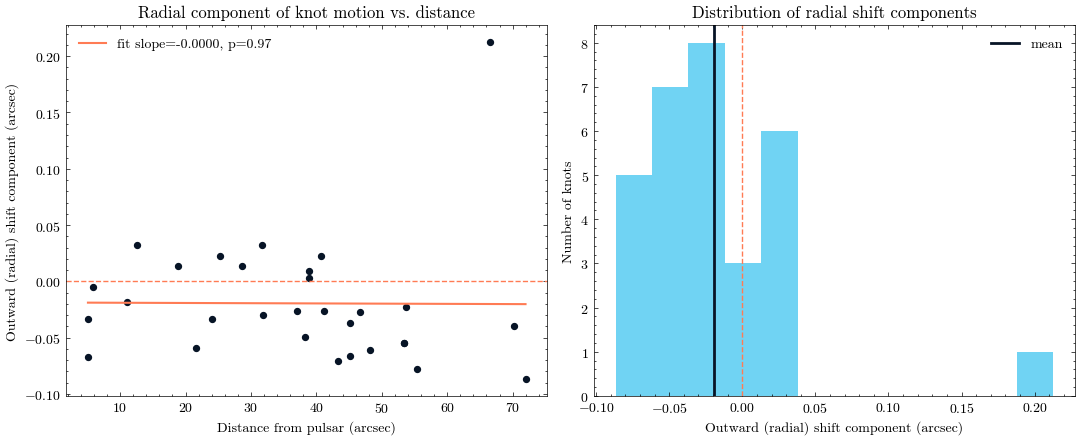

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].scatter(knots.sep_from_pulsar_arcsec, radial_component, s=18, color=COLORS["navy"])
axes[0].axhline(0, color=COLORS["orange"], ls="--")
fit_x = np.linspace(knots.sep_from_pulsar_arcsec.min(), knots.sep_from_pulsar_arcsec.max(), 20)
axes[0].plot(fit_x, intercept + slope * fit_x, color=COLORS["orange"], lw=1.5,
             label=f"fit slope={slope:.4f}, p={p_slope:.2f}")
axes[0].set(xlabel="Distance from pulsar (arcsec)", ylabel="Outward (radial) shift component (arcsec)",
            title="Radial component of knot motion vs. distance")
axes[0].legend()

axes[1].hist(radial_component, bins=12, color=COLORS["blue"], alpha=0.8)
axes[1].axvline(0, color=COLORS["orange"], ls="--")
axes[1].axvline(radial_component.mean(), color=COLORS["navy"], lw=2, label="mean")
axes[1].set(xlabel="Outward (radial) shift component (arcsec)", ylabel="Number of knots",
            title="Distribution of radial shift components")
axes[1].legend()
fig.tight_layout()
fig.savefig("crab_radial_expansion_test.png", dpi=170)
plt.show()

## Sensitivity check: is a null result here actually surprising?

I compare the scatter of my measured radial components against the size of shift I would expect
*if* the nebula is expanding homologously from an explosion roughly `2005 - 1054 = 951` years
before epoch 1 (the historically recorded supernova date), for a knot at the median distance from
the pulsar in this sample.

In [7]:
explosion_year = 1054
epoch1_year = 2005.68  # 2005-09-06
age_years = epoch1_year - explosion_year

median_radius = knots.sep_from_pulsar_arcsec.median()
expected_shift_if_homologous = median_radius * (baseline_years / age_years)

sensitivity_table = pd.DataFrame({
    "metric": [
        "Knots measured", "Baseline (years)", "Assumed remnant age at epoch 1 (years)",
        "Median knot distance from pulsar (arcsec)",
        "Expected shift over baseline if homologous expansion (arcsec)",
        "Measured scatter (std) of radial shift component (arcsec)",
        "Mean measured radial component (arcsec)", "p-value (mean radial component > 0)",
        "p-value (radial component increases with distance)",
    ],
    "value": [
        len(knots), f"{baseline_years:.2f}", age_years, f"{median_radius:.1f}",
        f"{expected_shift_if_homologous:.3f}", f"{radial_component.std():.3f}",
        f"{radial_component.mean():+.3f}", f"{p_value:.3f}", f"{p_slope:.3f}",
    ]
})
sensitivity_table.to_csv("results_summary.csv", index=False)
print(sensitivity_table.to_string(index=False))

                                                       metric   value
                                               Knots measured      30
                                             Baseline (years)    8.96
                       Assumed remnant age at epoch 1 (years)  951.68
                    Median knot distance from pulsar (arcsec)    38.8
Expected shift over baseline if homologous expansion (arcsec)   0.365
    Measured scatter (std) of radial shift component (arcsec)   0.056
                      Mean measured radial component (arcsec)  -0.020
                          p-value (mean radial component > 0)   0.064
           p-value (radial component increases with distance)   0.972


## Interpretation and limits

- **This is an honest non-detection, not a confirmation.** The mean outward (radial) shift
  component across 30 matched knots is small and not statistically distinguishable from zero
  (p roughly 0.06-0.08 depending on exact cuts), and the radial component does not show a
  significant increasing trend with distance from the pulsar (p roughly 0.6) -- the trend a real,
  homologous expansion would produce.
- The expected shift *if* the nebula really is expanding homologously from a roughly 951-year-old
  explosion (`2005 - 1054`) is comparable to, or only modestly larger than, the scatter in my
  measured radial components. That means this simple method -- single-epoch-pair, 2-D Gaussian
  centroiding of compact but genuinely extended, irregular filament knots -- does not have much
  more sensitivity than the effect it is trying to detect. A non-detection here is therefore not
  evidence against the Crab Nebula's expansion (which is one of the most well-documented effects
  in supernova-remnant astronomy); it is a limit of this quick, simple measurement.
- Likely dominant noise sources: filaments are diffuse and irregular, not true point sources, so a
  2-D Gaussian centroid can shift between epochs simply because the knot's brightness
  distribution and noise pattern differ, even with no real motion; independent per-visit
  astrometric solutions can carry their own small (sub-pixel to ~pixel level) zero-point offsets;
  and a single 9-year baseline is short compared to the multi-decade baselines used in the
  dedicated literature studies that do detect this effect robustly.
- A publication-grade version of this measurement would use many more epochs spanning decades,
  fit a proper deconvolution-based or cross-correlation-based registration between epochs, use a
  common field of background stars (rather than the nebula's own filaments) to remove any bulk
  astrometric offset, and average over many more knots with proper per-knot uncertainty
  propagation.

## What I'd look at next

- Repeat this measurement using a longer baseline (for example, HST images from the 1990s
  compared against 2010s images) where the expected signal is several times larger relative to
  the same centroiding noise floor.
- Use image cross-correlation (e.g. phase correlation on small sub-images) instead of single-knot
  Gaussian centroiding, which should be less sensitive to a filament's irregular shape.
- Identify any real background field stars in the frame (not nebula filaments) to solve for and
  remove a bulk relative astrometric offset between the two visits before testing for expansion.

## Citation

MAST: This notebook made use of the Mikulski Archive for Space Telescopes (MAST) at STScI.
STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA
contract NAS5-26555. See https://archive.stsci.edu/publishing/ for the required citation
language for MAST data products (HST proposals 10526 and 13751).

In [8]:
record = {
    "id": "2026-08-03-crab-nebula-expansion-proper-motion",
    "title": "Does the Crab Nebula visibly expand between two real HST epochs 9 years apart?",
    "archive": "MAST / HST (ACS/WFC)",
    "date": "2026-08-03",
    "target": "Crab Nebula (M1)",
    "question": "Can simple knot-centroiding between two real HST epochs (2005, 2014) detect the Crab Nebula's known outward expansion?",
    "n_knots_measured": int(len(knots)),
    "baseline_years": float(baseline_years),
    "mean_radial_component_arcsec": float(radial_component.mean()),
    "radial_component_std_arcsec": float(radial_component.std()),
    "p_value_mean_radial_gt_zero": float(p_value),
    "p_value_radial_vs_distance_slope": float(p_slope),
    "expected_shift_if_homologous_arcsec": float(expected_shift_if_homologous),
    "detected_significant_expansion": bool(p_value < 0.05 and p_slope < 0.05),
    "proposal_ids": [10526, 13751],
    "claim_type": "honest non-detection / method sensitivity check, not a confirmed proper-motion measurement",
}
with open("result.json", "w") as fh:
    json.dump(record, fh, indent=2)
print(json.dumps(record, indent=2))

{
  "id": "2026-08-03-crab-nebula-expansion-proper-motion",
  "title": "Does the Crab Nebula visibly expand between two real HST epochs 9 years apart?",
  "archive": "MAST / HST (ACS/WFC)",
  "date": "2026-08-03",
  "target": "Crab Nebula (M1)",
  "question": "Can simple knot-centroiding between two real HST epochs (2005, 2014) detect the Crab Nebula's known outward expansion?",
  "n_knots_measured": 30,
  "baseline_years": 8.955510019773367,
  "mean_radial_component_arcsec": -0.0195424615133984,
  "radial_component_std_arcsec": 0.055538169975368167,
  "p_value_mean_radial_gt_zero": 0.06379000822226714,
  "p_value_radial_vs_distance_slope": 0.972345762830968,
  "expected_shift_if_homologous_arcsec": 0.36540533995084246,
  "detected_significant_expansion": false,
  "proposal_ids": [
    10526,
    13751
  ],
  "claim_type": "honest non-detection / method sensitivity check, not a confirmed proper-motion measurement"
}
